In [2]:
# Strategic Analysis of Food Delivery Logistics Performance Using Data Science

## Week 1: Strategic Planning and Data Exploration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/zomato_cleaned.csv")

In [5]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [7]:
df.shape

(38964, 22)

In [9]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'distance_km', 'delivery_speed'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38964 entries, 0 to 38963
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           38964 non-null  object 
 1   Delivery_person_ID           38964 non-null  object 
 2   Delivery_person_Age          37945 non-null  float64
 3   Delivery_person_Ratings      37909 non-null  float64
 4   Restaurant_latitude          38964 non-null  float64
 5   Restaurant_longitude         38964 non-null  float64
 6   Delivery_location_latitude   38964 non-null  float64
 7   Delivery_location_longitude  38964 non-null  float64
 8   Order_Date                   38964 non-null  object 
 9   Time_Orderd                  38129 non-null  object 
 10  Time_Order_picked            38964 non-null  object 
 11  Weather_conditions           38964 non-null  object 
 12  Road_traffic_density         38964 non-null  object 
 13  Vehicle_conditio

In [11]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min),distance_km
count,37945.000000,37909.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000
mean,29.607089,4.631879,18.915583,76.914536,18.979545,76.978498,0.995534,0.749589,26.581511,9.765092
std,5.763202,0.317006,5.460635,3.498179,5.462504,3.498357,0.817312,0.572172,9.339546,5.605705
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.066047,73.938972,0.000000,0.000000,19.000000,4.658009
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.663067,1.000000,1.000000,26.000000,9.219906
75%,35.000000,4.900000,22.751234,78.368855,22.820072,78.405467,2.000000,1.000000,33.000000,13.681590
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,20.969489


In [12]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1019
Delivery_person_Ratings,1055
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,835


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df_clean = df.copy()

df_clean["Delivery_person_Age"] = df_clean["Delivery_person_Age"].fillna(
    df_clean["Delivery_person_Age"].median()
)

df_clean["Delivery_person_Ratings"] = df_clean["Delivery_person_Ratings"].fillna(
    df_clean["Delivery_person_Ratings"].median()
)

In [15]:
df_clean.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,835


In [16]:
df_clean.duplicated().sum()

np.int64(0)

In [17]:
df_clean["Time_taken (min)"].describe()

,Time_taken (min)
count,38964.000000
mean,26.581511
std,9.339546
min,10.000000
25%,19.000000
50%,26.000000
75%,33.000000
max,54.000000


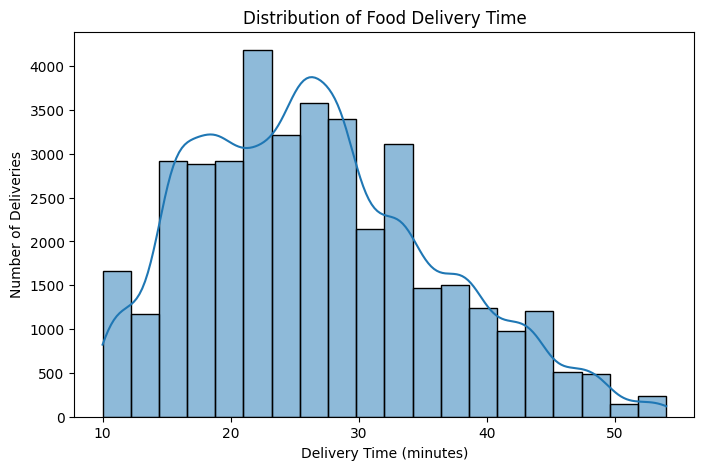

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Time_taken (min)"], bins=20, kde=True)

plt.title("Distribution of Food Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")

plt.show()

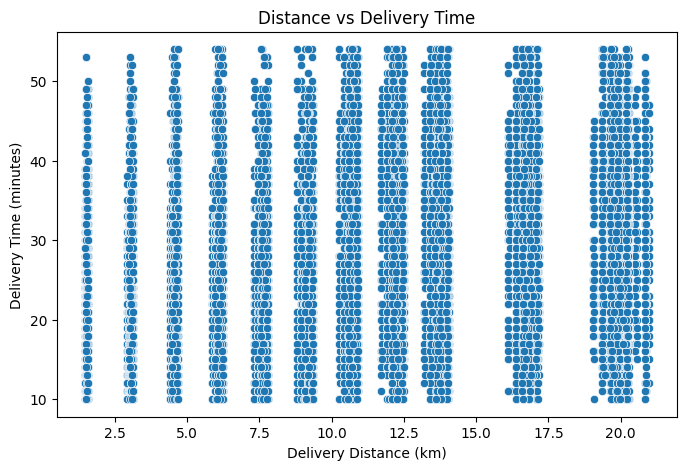

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="distance_km",
    y="Time_taken (min)"
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

In [20]:
average_delivery_time = df_clean["Time_taken (min)"].mean()

average_distance = df_clean["distance_km"].mean()

average_rating = df_clean["Delivery_person_Ratings"].mean()

print("Average Delivery Time:", round(average_delivery_time, 2), "minutes")
print("Average Delivery Distance:", round(average_distance, 2), "km")
print("Average Delivery Rating:", round(average_rating, 2))

Average Delivery Time: 26.58 minutes
Average Delivery Distance: 9.77 km
Average Delivery Rating: 4.63


In [21]:
traffic_analysis = df_clean.groupby(
    "Road_traffic_density"
)["Time_taken (min)"].mean().sort_values(ascending=False)

print(traffic_analysis)

Road_traffic_density
Jam       31.440229
High      27.413489
Medium    26.925701
Low       21.496461
Name: Time_taken (min), dtype: float64


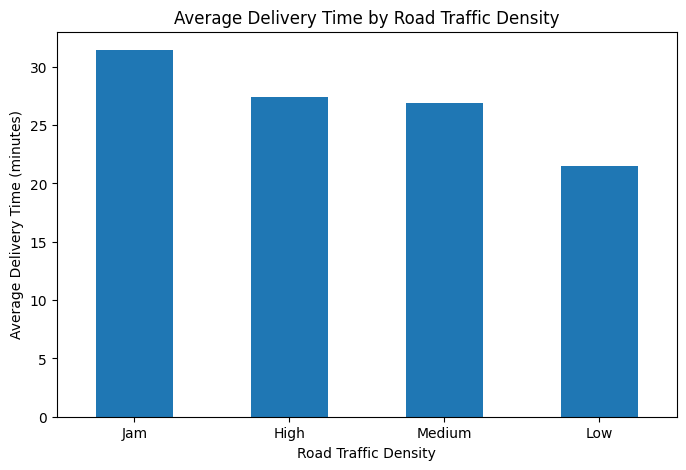

In [22]:
plt.figure(figsize=(8,5))

traffic_analysis.plot(kind="bar")

plt.title("Average Delivery Time by Road Traffic Density")
plt.xlabel("Road Traffic Density")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=0)
plt.show()

In [23]:
df_clean["Type_of_vehicle"].value_counts()

,count
Type_of_vehicle,
motorcycle,22942
scooter,12926
electric_scooter,3096


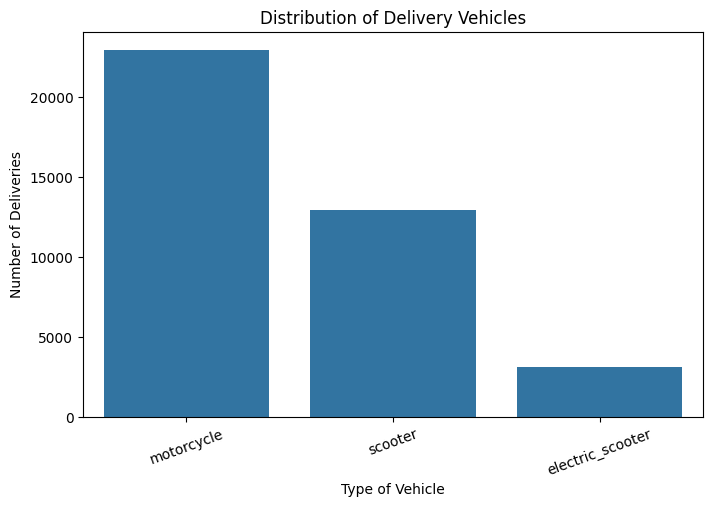

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Type_of_vehicle"
)

plt.title("Distribution of Delivery Vehicles")
plt.xlabel("Type of Vehicle")
plt.ylabel("Number of Deliveries")

plt.xticks(rotation=20)
plt.show()

In [25]:
vehicle_time = df_clean.groupby(
    "Type_of_vehicle"
)["Time_taken (min)"].mean().sort_values(ascending=False)

print(vehicle_time)

Type_of_vehicle
motorcycle          27.854677
scooter             24.805818
electric_scooter    24.560724
Name: Time_taken (min), dtype: float64


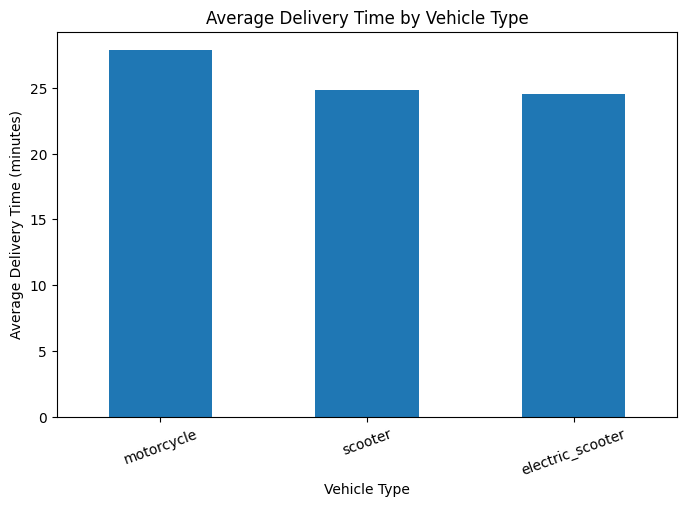

In [26]:
plt.figure(figsize=(8,5))

vehicle_time.plot(kind="bar")

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=20)
plt.show()

In [27]:
df_clean["City"].value_counts()

,count
City,
Metropolitian,30036
Urban,8782
Semi-Urban,146


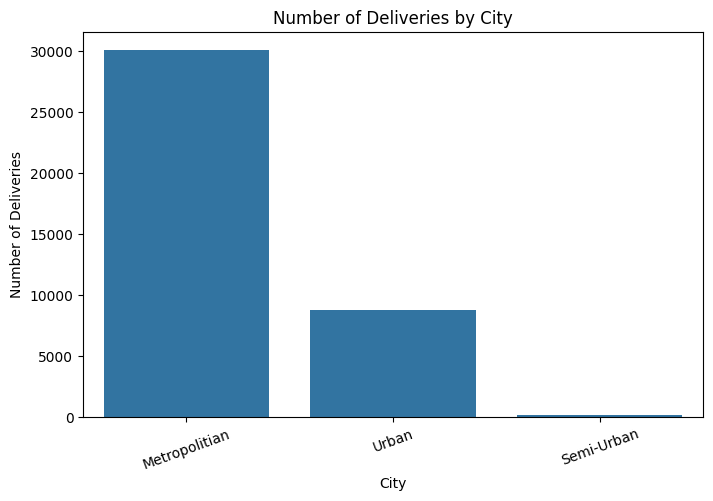

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="City"
)

plt.title("Number of Deliveries by City")
plt.xlabel("City")
plt.ylabel("Number of Deliveries")

plt.xticks(rotation=20)
plt.show()

In [29]:
city_time = df_clean.groupby(
    "City"
)["Time_taken (min)"].mean().sort_values(ascending=False)

print(city_time)

City
Semi-Urban       49.691781
Metropolitian    27.445199
Urban            23.243339
Name: Time_taken (min), dtype: float64


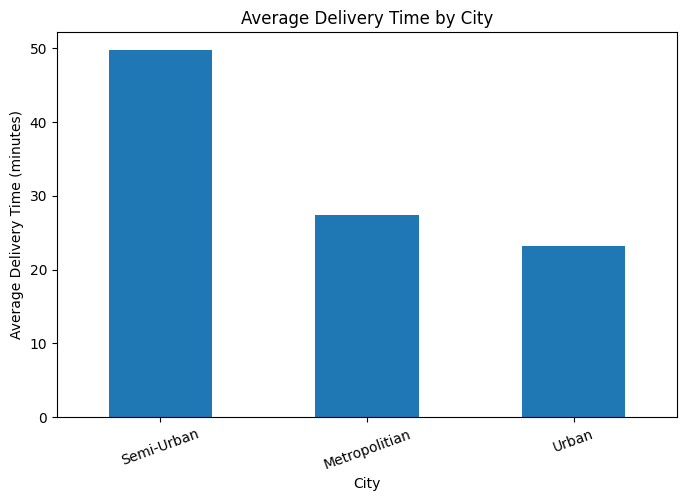

In [30]:
plt.figure(figsize=(8,5))

city_time.plot(kind="bar")

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=20)
plt.show()

In [31]:
df_clean["Weather_conditions"].value_counts()

,count
Weather_conditions,
Fog,6660
Stormy,6572
Cloudy,6563
Sandstorms,6489
Windy,6436
Sunny,6244


In [32]:
weather_time = df_clean.groupby(
    "Weather_conditions"
)["Time_taken (min)"].mean().sort_values(ascending=False)

print(weather_time)

Weather_conditions
Fog           29.220420
Cloudy        29.154655
Windy         26.388440
Stormy        26.146835
Sandstorms    26.121590
Sunny         22.196669
Name: Time_taken (min), dtype: float64


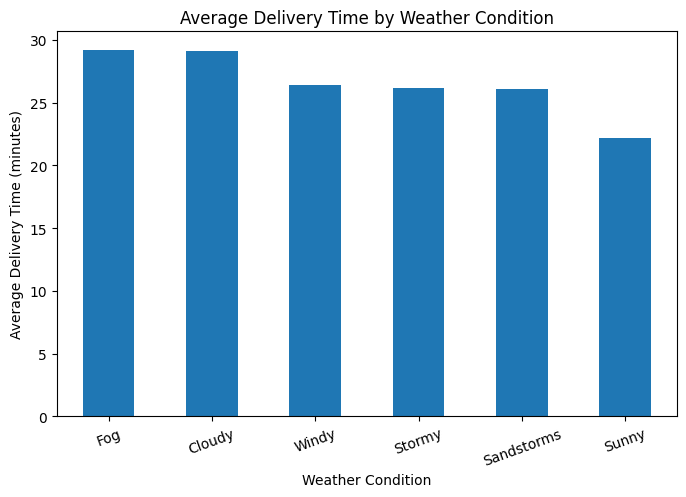

In [33]:
plt.figure(figsize=(8,5))

weather_time.plot(kind="bar")

plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=20)
plt.show()

In [34]:
df_clean["multiple_deliveries"].value_counts().sort_index()

,count
multiple_deliveries,
0.0,12165
1.0,24704
2.0,1782
3.0,313


In [35]:
multiple_delivery_time = df_clean.groupby(
    "multiple_deliveries"
)["Time_taken (min)"].mean()

print(multiple_delivery_time)

multiple_deliveries
0.0    23.155446
1.0    26.995952
2.0    40.489338
3.0    47.846645
Name: Time_taken (min), dtype: float64


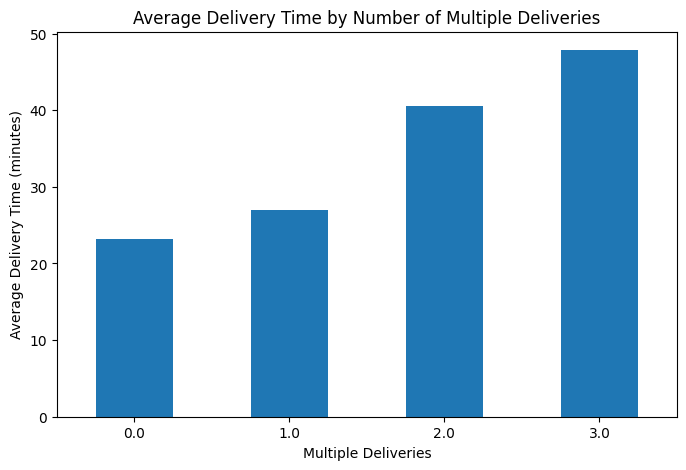

In [36]:
plt.figure(figsize=(8,5))

multiple_delivery_time.plot(kind="bar")

plt.title("Average Delivery Time by Number of Multiple Deliveries")
plt.xlabel("Multiple Deliveries")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=0)
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [39]:
X = df_clean[["distance_km"]]
y = df_clean["Time_taken (min)"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
model = LinearRegression()

In [44]:
model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_pred = model.predict(X_test)

In [46]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 4))

R² Score: 0.1084


In [47]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", round(mae, 2), "minutes")

MAE: 7.07 minutes


In [48]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", round(rmse, 2), "minutes")

RMSE: 8.71 minutes


In [49]:
print("Model Performance")
print("-----------------")
print("R² Score:", round(r2, 4))
print("MAE:", round(mae, 2), "minutes")
print("RMSE:", round(rmse, 2), "minutes")

Model Performance
-----------------
R² Score: 0.1084
MAE: 7.07 minutes
RMSE: 8.71 minutes


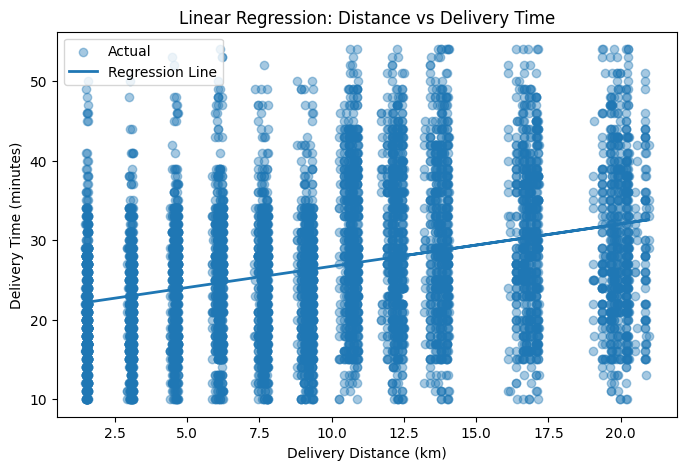

In [50]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, alpha=0.4, label="Actual")

plt.plot(
    X_test,
    y_pred,
    linewidth=2,
    label="Regression Line"
)

plt.title("Linear Regression: Distance vs Delivery Time")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.legend()

plt.show()

In [51]:
categorical_cols = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

for col in categorical_cols:
    print("\n", col)
    print(df_clean[col].value_counts())


 Weather_conditions
Weather_conditions
Fog           6660
Stormy        6572
Cloudy        6563
Sandstorms    6489
Windy         6436
Sunny         6244
Name: count, dtype: int64

 Road_traffic_density
Road_traffic_density
Low       13139
Jam       12414
Medium     9556
High       3855
Name: count, dtype: int64

 Type_of_order
Type_of_order
Snack     9815
Meal      9774
Drinks    9751
Buffet    9624
Name: count, dtype: int64

 Type_of_vehicle
Type_of_vehicle
motorcycle          22942
scooter             12926
electric_scooter     3096
Name: count, dtype: int64

 Festival
Festival
No     38180
Yes      784
Name: count, dtype: int64

 City
City
Metropolitian    30036
Urban             8782
Semi-Urban         146
Name: count, dtype: int64


In [52]:
features = [
    "distance_km",
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

X = df_clean[features]
y = df_clean["Time_taken (min)"]

In [53]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [54]:
print("Original number of features:", X.shape[1])
print("Encoded number of features:", X_encoded.shape[1])

Original number of features: 11
Encoded number of features: 21


In [55]:
X_encoded.head()

,distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,...,Road_traffic_density_Low,Road_traffic_density_Medium,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban
0,10.280582,36.0,4.2,2,3.0,True,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
1,6.242319,21.0,4.7,1,1.0,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
2,13.787860,23.0,4.7,1,1.0,False,True,False,False,False,...,False,True,True,False,False,False,True,False,False,False
3,2.930258,34.0,4.3,0,0.0,False,True,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4,19.396618,24.0,4.7,1,1.0,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

LinearRegression()

In [58]:
y_pred_multiple = multiple_model.predict(X_test)

In [59]:
r2_multiple = r2_score(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(
    mean_squared_error(y_test, y_pred_multiple)
)

print("Multiple Linear Regression Results")
print("-----------------------------------")
print("R² Score:", round(r2_multiple, 4))
print("MAE:", round(mae_multiple, 2), "minutes")
print("RMSE:", round(rmse_multiple, 2), "minutes")

Multiple Linear Regression Results
-----------------------------------
R² Score: 0.5903
MAE: 4.69 minutes
RMSE: 5.9 minutes


In [60]:
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": multiple_model.coef_
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
19,City_Semi-Urban,9.925613,9.925613
18,Festival_Yes,9.397912,9.397912
2,Delivery_person_Ratings,-7.458866,7.458866
11,Road_traffic_density_Low,-6.611368,6.611368
8,Weather_conditions_Sunny,-6.154981,6.154981
4,multiple_deliveries,2.889393,2.889393
7,Weather_conditions_Stormy,-2.851272,2.851272
6,Weather_conditions_Sandstorms,-2.806356,2.806356
9,Weather_conditions_Windy,-2.722462,2.722462
12,Road_traffic_density_Medium,-2.465860,2.465860


In [61]:
model_names = ["Simple Linear Regression", "Multiple Linear Regression"]

r2_scores = [0.1084, r2_multiple]
mae_scores = [7.07, mae_multiple]
rmse_scores = [8.71, rmse_multiple]

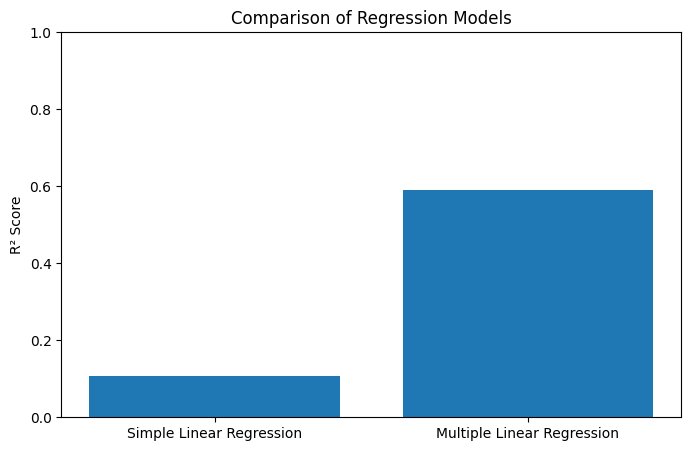

In [62]:
plt.figure(figsize=(8,5))

plt.bar(model_names, r2_scores)

plt.title("Comparison of Regression Models")
plt.ylabel("R² Score")

plt.ylim(0, 1)

plt.show()

In [63]:
cluster_features = df_clean[
    ["distance_km", "Time_taken (min)", "Delivery_person_Ratings"]
]

cluster_features.head()


,distance_km,Time_taken (min),Delivery_person_Ratings
0,10.280582,46,4.2
1,6.242319,23,4.7
2,13.787860,21,4.7
3,2.930258,20,4.3
4,19.396618,41,4.7


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_features)

In [65]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

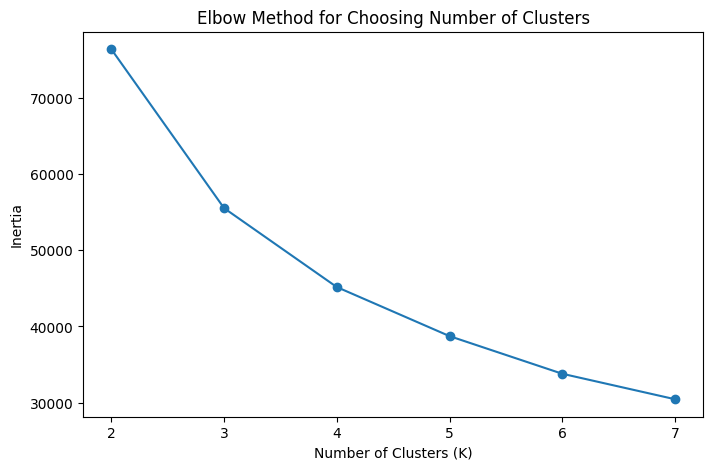

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 8),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()


In [67]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

In [68]:
df_clean["Cluster"].value_counts().sort_index()

,count
Cluster,
0,9995
1,4892
2,10045
3,8858
4,5174


In [69]:
cluster_summary = df_clean.groupby("Cluster")[
    ["distance_km", "Time_taken (min)", "Delivery_person_Ratings"]
].mean().round(2)

cluster_summary

,distance_km,Time_taken (min),Delivery_person_Ratings
Cluster,,,
0,6.14,28.03,4.72
1,14.82,40.89,4.69
2,5.07,16.80,4.74
3,15.42,22.51,4.75
4,11.43,36.22,4.01


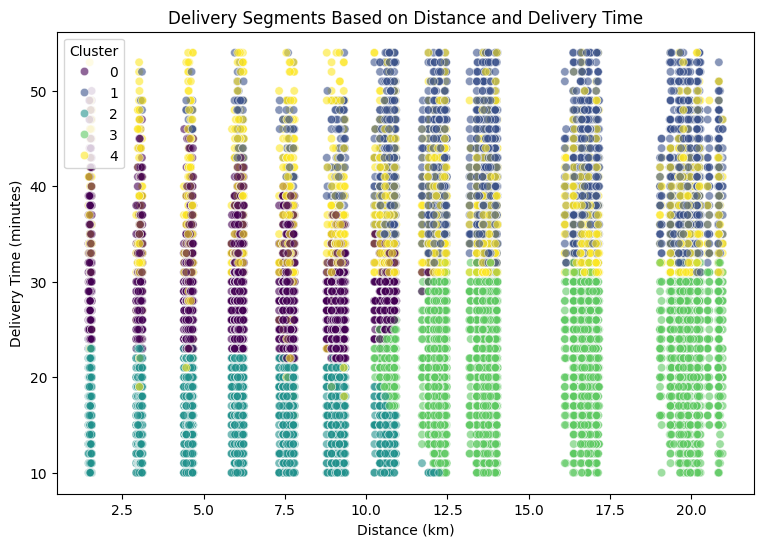

In [70]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_clean,
    x="distance_km",
    y="Time_taken (min)",
    hue="Cluster",
    palette="viridis",
    alpha=0.6
)

plt.title("Delivery Segments Based on Distance and Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.legend(title="Cluster")

plt.show()

In [71]:
# Simple logistics optimization framework

optimization_objectives = [
    "Minimize delivery time",
    "Reduce transportation cost",
    "Improve rider/resource utilization",
    "Prioritize high-delay delivery segments"
]

optimization_constraints = [
    "Limited number of delivery riders",
    "Vehicle availability",
    "Delivery distance",
    "Traffic conditions",
    "Delivery capacity"
]

print("Optimization Objectives:")
for objective in optimization_objectives:
    print("-", objective)

print("\nOptimization Constraints:")
for constraint in optimization_constraints:
    print("-", constraint)

Optimization Objectives:
- Minimize delivery time
- Reduce transportation cost
- Improve rider/resource utilization
- Prioritize high-delay delivery segments

Optimization Constraints:
- Limited number of delivery riders
- Vehicle availability
- Delivery distance
- Traffic conditions
- Delivery capacity
